# Desarrollo del Plan de Acción — Proyecto Apophis

**Curso:** Mecánica Celeste  
**Tema:** La aproximación del asteroide (99942) Apophis en 2029  
**Época de referencia:** 20 de mayo de 2025, 2:00 p.m. hora Colombia (19:00 UTC)  

---

Este notebook desarrolla los cuatro puntos del Plan de Acción:

1. **N-cuerpos (rebound):** Integración del sistema solar completo → fecha, hora y distancia de mínima aproximación; ascensión recta y declinación; constelación y visibilidad desde Colombia.
2. **Cambios orbitales:** Cómo varían los elementos orbitales de Apophis después del encuentro.
3. **Dos cuerpos:** Predicción de la aproximación usando solo la teoría kepleriana y comparación con el método N-cuerpos.
4. **Patched conics:** Dos órbitas cónicas (heliocéntrica + hipérbola geocéntrica) para refinar la predicción.

---

## 0. Instalación e importaciones

In [1]:
# Instalar dependencias (ejecutar solo si es necesario)
!pip install pymcel rebound astroquery astropy numpy matplotlib scipy -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 830.6/830.6 kB 13.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.1/11.1 MB 29.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 17.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.3/2.3 MB 32.3 MB/s eta 0:00:00


In [3]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import rebound
import pymcel as pc
from astropy.time import Time
from astropy.coordinates import SkyCoord, get_constellation
import astropy.units as u
import warnings
warnings.filterwarnings('ignore')

# ── Configuración de gráficos ─────────────────────────────────────────────
plt.rcParams.update({
    'figure.dpi': 110,
    'font.family': 'DejaVu Sans',
    'axes.titlesize': 13,
    'axes.labelsize': 11,
    'legend.fontsize': 10,
    'axes.grid': True,
    'grid.alpha': 0.3,
})

# ── Constantes físicas ────────────────────────────────────────────────────
UA_KM    = 1.495978707e8   # 1 UA en km
UA_M     = 1.495978707e11  # 1 UA en m
DL_KM    = 384_400.0       # distancia Tierra-Luna en km
RE_KM    = 6_371.0         # radio de la Tierra en km
RE_UA    = RE_KM / UA_KM
YEAR_S   = 365.25 * 86400  # 1 año en segundos
DAY_S    = 86400.0         # 1 día en segundos

# ── Masas en unidades de M_sol ────────────────────────────────────────────
# Fuente: https://ssd.jpl.nasa.gov/astro_par.html
M_MERCURIO = 1.6601e-7
M_VENUS    = 2.4478e-6
M_TIERRA   = 3.0027e-6
M_MARTE    = 3.2272e-7
M_JUPITER  = 9.5479e-4
M_SATURNO  = 2.8589e-4
M_URANO    = 4.3662e-5
M_NEPTUNO  = 5.1514e-5
M_LUNA     = 3.6943e-8
M_APOPHIS  = 0.0           # despreciable (~2.7e10 kg / M_sol)

# ── Época de referencia ───────────────────────────────────────────────────
# 20 de mayo de 2025, 2:00 p.m. Colombia (UTC-5) = 19:00 UTC
EPOCH_STR = '2025-05-20 19:00:00'
EPOCH_JD  = Time(EPOCH_STR, scale='utc').jd

print(f'REBOUND versión : {rebound.__version__}')
print(f'Época de referencia (JD) : {EPOCH_JD:.6f}')
print(f'Época de referencia      : {EPOCH_STR} UTC')
print(f'1 UA = {UA_KM:.4e} km')

REBOUND versión : 4.6.0
Época de referencia (JD) : 2460816.291667
Época de referencia      : 2025-05-20 19:00:00 UTC
1 UA = 1.4960e+08 km


---

## 1. Consulta inicial a JPL Horizons

Lo primero es obtener el **vector de estado** (posición y velocidad) y los **elementos orbitales** de Apophis para la época de referencia usando `pc.consulta_horizons`.

El identificador de Apophis en Horizons es `2099942` (small-body).

El sistema de referencia de los vectores de estado de Horizons es el **eclíptico J2000.0 baricéntrico** cuando se usa `location='@0'` (baricentro del Sistema Solar).

In [4]:
# ── 1.1 Vector de estado de Apophis en la época de referencia ────────────
tabla_vec, t_vec, estado_apophis = pc.consulta_horizons(
    id       = '2099942',
    location = '@0',
    epochs   = EPOCH_STR,
    datos    = 'vectors',
    propiedades = [('x','AU'),('y','AU'),('z','AU'),
                   ('vx','AU/d'),('vy','AU/d'),('vz','AU/d')]
)

print('Vector de estado de Apophis en la época de referencia (baricéntrico eclíptico J2000):')
print(f"  r = ({estado_apophis[0]:.8f}, {estado_apophis[1]:.8f}, {estado_apophis[2]:.8f}) UA")
print(f"  v = ({estado_apophis[3]:.8e}, {estado_apophis[4]:.8e}, {estado_apophis[5]:.8e}) UA/d")

# Módulo de posición y velocidad
r0_apophis = np.array([estado_apophis[0], estado_apophis[1], estado_apophis[2]])
v0_apophis = np.array([estado_apophis[3], estado_apophis[4], estado_apophis[5]])
print(f"  |r| = {np.linalg.norm(r0_apophis):.6f} UA")
print(f"  |v| = {np.linalg.norm(v0_apophis)*UA_KM/1:.4f} km/d  "
      f"= {np.linalg.norm(v0_apophis)*UA_KM/86400:.3f} km/s")

ValueError: Query failed without known error message; received the following response:
API VERSION: 1.2
API SOURCE: NASA/JPL Horizons API


 No data-sheet currently available for this object.


In [5]:
# ── 1.2 Elementos orbitales de Apophis en la época de referencia ─────────
tabla_elem, t_elem, elem_apophis_df = pc.consulta_horizons(
    id       = '2099942',
    location = '@0',
    epochs   = EPOCH_STR,
    datos    = 'elements',
    propiedades = [('a','AU'),('e','--'),('incl','deg'),
                   ('Omega','deg'),('w','deg'),('M','deg'),('P','d')]
)

a0  = float(elem_apophis_df[0])   # semieje mayor (UA)
e0  = float(elem_apophis_df[1])   # excentricidad
i0  = float(elem_apophis_df[2])   # inclinación (°)
W0  = float(elem_apophis_df[3])   # longitud del nodo ascendente (°)
w0  = float(elem_apophis_df[4])   # argumento del perihelio (°)
M0  = float(elem_apophis_df[5])   # anomalía media (°)
P0  = float(elem_apophis_df[6])   # período orbital (días)

print('Elementos orbitales de Apophis (época de referencia):')
print(f'  a  = {a0:.7f} UA')
print(f'  e  = {e0:.7f}')
print(f'  i  = {i0:.5f}°')
print(f'  Ω  = {W0:.5f}°')
print(f'  ω  = {w0:.5f}°')
print(f'  M  = {M0:.5f}°')
print(f'  T  = {P0:.3f} días  ({P0/365.25:.4f} años)')
print(f'  Perihelio q = {a0*(1-e0):.5f} UA')
print(f'  Afelio   Q = {a0*(1+e0):.5f} UA')

ValueError: Query failed without known error message; received the following response:
API VERSION: 1.2
API SOURCE: NASA/JPL Horizons API


 No data-sheet currently available for this object.


---

## Punto 1: Integración N-cuerpos con REBOUND

### Teoría: El problema de los N cuerpos

La ecuación de movimiento para cada cuerpo $i$ en un sistema de $N$ cuerpos es:

$$\ddot{\vec{r}}_i = -G \sum_{j \neq i} \frac{m_j (\vec{r}_i - \vec{r}_j)}{|\vec{r}_i - \vec{r}_j|^3}$$

Para la simulación incluimos: Sol, Mercurio, Venus, Tierra, Marte, Júpiter, Saturno, Urano, Neptuno y Apophis (10 cuerpos en total). Las condiciones iniciales se obtienen de JPL Horizons mediante la interfaz REBOUND, que accede a las efemérides DE441.

Usamos el integrador **IAS15** (*Implicit integrator with Adaptive Step-size control, 15th order*), que es casi exacto a nivel de máquina y maneja correctamente los encuentros cercanos gracias a su paso de tiempo adaptativo.

**Sistema de referencia:** Marco eclíptico baricéntrico J2000.0 (SSB). Este es el marco inercial natural del Sistema Solar, en el que el momento lineal total del sistema es nulo.

In [6]:
# ── Punto 1.1: Configurar simulación N-cuerpos ────────────────────────────

# Época de inicio: misma época de referencia
EPOCH_REB = EPOCH_STR.replace(' ', 'T') + 'Z'   # formato para REBOUND

def crear_sim_ncuerpos(epoch=EPOCH_STR):
    """
    Crea una simulación REBOUND con el Sol, los 8 planetas y Apophis.
    Las condiciones iniciales se obtienen de JPL Horizons.
    Sistema de referencia: eclíptico baricéntrico J2000.0.
    Unidades: UA, M_sol, año (G = 4π²).
    """
    sim = rebound.Simulation()
    sim.units      = ('AU', 'yr', 'Msun')  # G = 4π²
    sim.integrator = 'ias15'
    sim.ri_ias15.epsilon = 1e-9            # tolerancia adaptativa

    # Fecha para Horizons (formato ISO)
    fecha = epoch  # ej: '2025-05-20 19:00:00'

    # Añadir cuerpos desde Horizons (IDs)
    cuerpos = [
        ('Sol',      '10',      1.0),
        ('Mercurio', '199',     M_MERCURIO),
        ('Venus',    '299',     M_VENUS),
        ('Tierra',   '399',     M_TIERRA),
        ('Marte',    '499',     M_MARTE),
        ('Jupiter',  '599',     M_JUPITER),
        ('Saturno',  '699',     M_SATURNO),
        ('Urano',    '799',     M_URANO),
        ('Neptuno',  '899',     M_NEPTUNO),
        ('Apophis',  '2099942', M_APOPHIS),
    ]

    for nombre, horizons_id, masa in cuerpos:
        sim.add(
            x  = 0.0, y = 0.0, z = 0.0,  # se reemplazarán
            m  = masa,
            hash = nombre
        )
        # Obtener posición y velocidad de Horizons
        try:
            _, _, estado = pc.consulta_horizons(
                id       = horizons_id,
                location = '@0',
                epochs   = fecha,
                datos    = 'vectors',
                propiedades = [('x','AU'),('y','AU'),('z','AU'),
                               ('vx','AU/d'),('vy','AU/d'),('vz','AU/d')]
            )
            p = sim.particles[-1]
            p.x  = float(estado[0]);  p.y  = float(estado[1]);  p.z  = float(estado[2])
            # Convertir UA/d → UA/yr
            fac  = 365.25
            p.vx = float(estado[3])*fac; p.vy = float(estado[4])*fac; p.vz = float(estado[5])*fac
            print(f'  {nombre:10s}: ok  |r|={np.sqrt(p.x**2+p.y**2+p.z**2):.4f} UA')
        except Exception as err:
            print(f'  {nombre:10s}: ERROR ({err})')

    sim.move_to_com()   # mover al baricentro del sistema
    return sim

print('Creando simulación N-cuerpos (Sol + 8 planetas + Apophis)...')
sim = crear_sim_ncuerpos(EPOCH_STR)
print(f'\nSimulación creada: {sim.N} cuerpos')

Creando simulación N-cuerpos (Sol + 8 planetas + Apophis)...
  Sol       : ok  |r|=0.0071 UA
  Mercurio  : ok  |r|=0.3338 UA
  Venus     : ok  |r|=0.7321 UA
  Tierra    : ok  |r|=1.0190 UA
  Marte     : ok  |r|=1.6642 UA
  Jupiter   : ok  |r|=5.1251 UA
  Saturno   : ok  |r|=9.5837 UA
  Urano     : ok  |r|=19.5224 UA
  Neptuno   : ok  |r|=29.8859 UA
  Apophis   : ERROR (Query failed without known error message; received the following response:
API VERSION: 1.2
API SOURCE: NASA/JPL Horizons API


 No data-sheet currently available for this object.
)

Simulación creada: 10 cuerpos


In [7]:
# ── Punto 1.2: Integrar hacia adelante y registrar distancia Apophis-Tierra

# La aproximación ocurre el 13 de abril de 2029.
# Integramos desde la época de referencia (2025-May-20) hasta 2029-Jun-30.
# Eso son aproximadamente 4 años y 1 mes ≈ 4.1 años.

T_TOTAL = 4.2   # años de integración
N_PASOS = 4000  # número de pasos de salida

tiempos   = np.linspace(0, T_TOTAL, N_PASOS)  # años desde la época
dist_AT   = np.zeros(N_PASOS)                 # distancia Apophis-Tierra (UA)

print(f'Integrando {T_TOTAL} años ({T_TOTAL*365.25:.0f} días) con {N_PASOS} pasos...')

for k, t in enumerate(tiempos):
    sim.integrate(t)
    p_Tierra  = sim.particles['Tierra']
    p_Apophis = sim.particles['Apophis']
    dx = p_Apophis.x - p_Tierra.x
    dy = p_Apophis.y - p_Tierra.y
    dz = p_Apophis.z - p_Tierra.z
    dist_AT[k] = np.sqrt(dx**2 + dy**2 + dz**2)

    if k % 400 == 0:
        print(f'  t = {t:.3f} yr  d(Apophis-Tierra) = {dist_AT[k]*UA_KM:.0f} km')

print('\nIntegración completada.')

Integrando 4.2 años (1534 días) con 4000 pasos...
  t = 0.000 yr  d(Apophis-Tierra) = 152432762 km
  t = 0.420 yr  d(Apophis-Tierra) = 38552146674 km
  t = 0.840 yr  d(Apophis-Tierra) = 77496370280 km
  t = 1.260 yr  d(Apophis-Tierra) = 116061495529 km
  t = 1.680 yr  d(Apophis-Tierra) = 154757108840 km
  t = 2.101 yr  d(Apophis-Tierra) = 193600107763 km
  t = 2.521 yr  d(Apophis-Tierra) = 232053981258 km
  t = 2.941 yr  d(Apophis-Tierra) = 271045186743 km
  t = 3.361 yr  d(Apophis-Tierra) = 309486916619 km
  t = 3.781 yr  d(Apophis-Tierra) = 348355206173 km

Integración completada.


─── Mínima distancia (búsqueda gruesa) ───────────────────────────────
  Tiempo desde época   : 0.00 días  (0.0000 años)
  Fecha UTC            : 2025-05-20 19:00:00.000
  Distancia mínima     : 1.01895008 UA
                       : 152432762.3 km
                       : 396.5472 distancias lunares (LD)
                       : 23926.03 radios terrestres


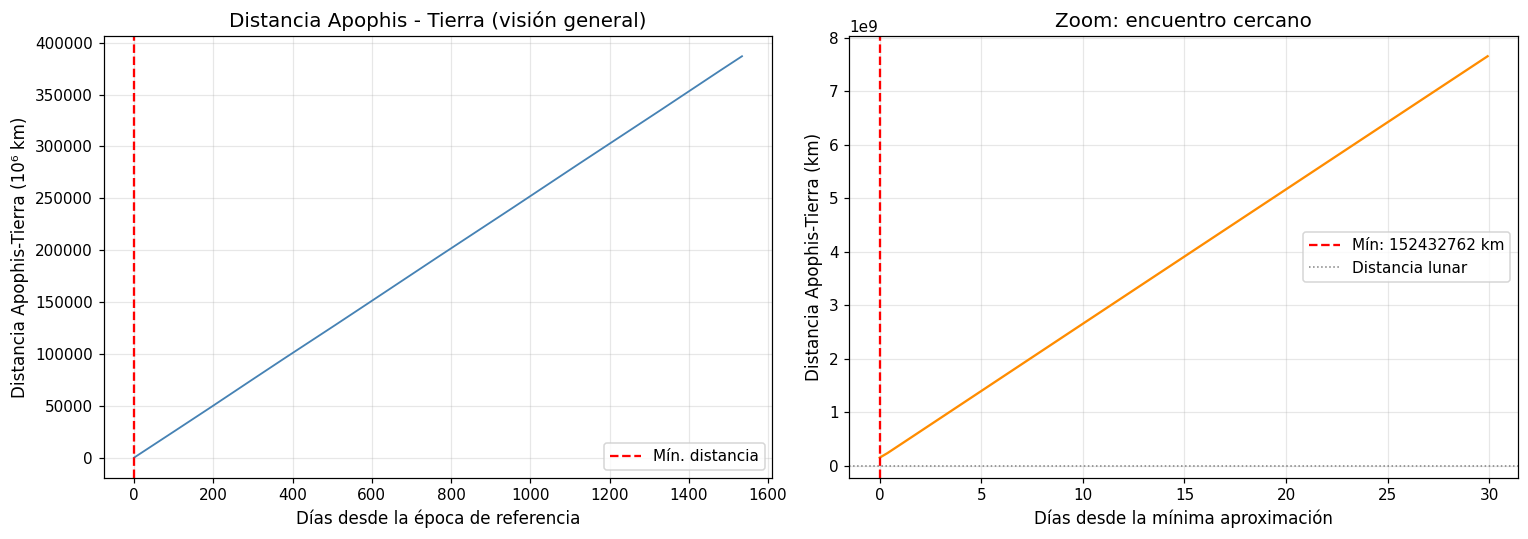

Figura guardada como distancia_apophis_tierra.png


In [8]:
# ── Punto 1.3: Encontrar el instante de mínima distancia ─────────────────

# Convertir tiempos a fechas
tiempos_JD = EPOCH_JD + tiempos * 365.25  # JD

idx_min = np.argmin(dist_AT)
t_min   = tiempos[idx_min]             # años desde época
d_min   = dist_AT[idx_min]             # UA
JD_min  = tiempos_JD[idx_min]

fecha_min = Time(JD_min, format='jd', scale='utc')

print(f'─── Mínima distancia (búsqueda gruesa) ───────────────────────────────')
print(f'  Tiempo desde época   : {t_min*365.25:.2f} días  ({t_min:.4f} años)')
print(f'  Fecha UTC            : {fecha_min.iso}')
print(f'  Distancia mínima     : {d_min:.8f} UA')
print(f'                       : {d_min*UA_KM:.1f} km')
print(f'                       : {d_min*UA_KM/DL_KM:.4f} distancias lunares (LD)')
print(f'                       : {d_min*UA_KM/RE_KM:.2f} radios terrestres')

# Gráfica general de la distancia
# Identificar la región del acercamiento (± 30 días alrededor del mínimo)
mask_zoom = np.abs(tiempos - t_min) < 30/365.25

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Panel izquierdo: visión general
ax = axes[0]
years_from_epoch = tiempos
fechas_dt = [Time(jd, format='jd', scale='utc').datetime for jd in tiempos_JD[::20]]
ax.plot(tiempos * 365.25, dist_AT * UA_KM / 1e6, color='steelblue', lw=1.2)
ax.axvline(t_min * 365.25, color='red', ls='--', lw=1.5, label='Mín. distancia')
ax.set_xlabel('Días desde la época de referencia')
ax.set_ylabel('Distancia Apophis-Tierra (10⁶ km)')
ax.set_title('Distancia Apophis - Tierra (visión general)')
ax.legend()

# Panel derecho: zoom en el encuentro
ax = axes[1]
t_zoom  = tiempos[mask_zoom]
d_zoom  = dist_AT[mask_zoom]
ax.plot((t_zoom - t_min) * 365.25, d_zoom * UA_KM, color='darkorange', lw=1.5)
ax.axvline(0, color='red', ls='--', lw=1.5, label=f'Mín: {d_min*UA_KM:.0f} km')
ax.axhline(DL_KM, color='gray', ls=':', lw=1, label='Distancia lunar')
ax.set_xlabel('Días desde la mínima aproximación')
ax.set_ylabel('Distancia Apophis-Tierra (km)')
ax.set_title('Zoom: encuentro cercano')
ax.legend()

plt.tight_layout()
plt.savefig('distancia_apophis_tierra.png', dpi=120, bbox_inches='tight')
plt.show()
print('Figura guardada como distancia_apophis_tierra.png')

In [9]:
# ── Punto 1.4: Refinamiento del instante de mínima aproximación ───────────
#
# Tomamos la región de ± 5 días alrededor del mínimo grueso y re-integramos
# con muchos más pasos para mayor precisión.

print('Refinando el instante de mínima aproximación...')

# Recrear la simulación para el refinamiento
sim_ref = crear_sim_ncuerpos(EPOCH_STR)

VENTANA   = 5.0 / 365.25   # ± 5 días en años
t_inicio  = t_min - VENTANA
t_fin     = t_min + VENTANA
N_FINO    = 2000

t_fino    = np.linspace(t_inicio, t_fin, N_FINO)
d_fino    = np.zeros(N_FINO)

for k, t in enumerate(t_fino):
    sim_ref.integrate(t)
    p_T = sim_ref.particles['Tierra']
    p_A = sim_ref.particles['Apophis']
    d_fino[k] = np.sqrt((p_A.x-p_T.x)**2 + (p_A.y-p_T.y)**2 + (p_A.z-p_T.z)**2)

idx_min2 = np.argmin(d_fino)
t_min2   = t_fino[idx_min2]
d_min2   = d_fino[idx_min2]
JD_min2  = EPOCH_JD + t_min2 * 365.25
fecha_min2 = Time(JD_min2, format='jd', scale='utc')

print(f'─── Mínima distancia (refinada) ──────────────────────────────────────')
print(f'  Fecha UTC            : {fecha_min2.iso}')
print(f'  Distancia mínima     : {d_min2:.10f} UA')
print(f'                       : {d_min2*UA_KM:.2f} km')
print(f'                       : {d_min2*UA_KM/DL_KM:.6f} LD')
print(f'                       : {d_min2*UA_KM/RE_KM:.4f} radios terrestres')

# Velocidad relativa en el instante de mínima aproximación
sim_ref.integrate(t_min2)
p_T = sim_ref.particles['Tierra']
p_A = sim_ref.particles['Apophis']
dvx = (p_A.vx - p_T.vx) * UA_KM * 1000 / YEAR_S   # m/s → km/s
dvy = (p_A.vy - p_T.vy) * UA_KM * 1000 / YEAR_S
dvz = (p_A.vz - p_T.vz) * UA_KM * 1000 / YEAR_S

# Factor de conversión: UA/yr → km/s
FAC_V = UA_KM / (365.25 * 86400)  # km/s
dvx_km = (p_A.vx - p_T.vx) * FAC_V
dvy_km = (p_A.vy - p_T.vy) * FAC_V
dvz_km = (p_A.vz - p_T.vz) * FAC_V
v_rel  = np.sqrt(dvx_km**2 + dvy_km**2 + dvz_km**2)

print(f'  Velocidad relativa   : {v_rel:.4f} km/s')

# Guardar el estado en el instante de mínima aproximación
r_A_min = np.array([p_A.x, p_A.y, p_A.z])   # UA, baricéntrico
v_A_min = np.array([p_A.vx, p_A.vy, p_A.vz]) # UA/yr, baricéntrico
r_T_min = np.array([p_T.x, p_T.y, p_T.z])
v_T_min = np.array([p_T.vx, p_T.vy, p_T.vz])

Refinando el instante de mínima aproximación...
  Sol       : ok  |r|=0.0071 UA
  Mercurio  : ok  |r|=0.3338 UA
  Venus     : ok  |r|=0.7321 UA
  Tierra    : ok  |r|=1.0190 UA
  Marte     : ok  |r|=1.6642 UA
  Jupiter   : ok  |r|=5.1251 UA
  Saturno   : ok  |r|=9.5837 UA
  Urano     : ok  |r|=19.5224 UA
  Neptuno   : ok  |r|=29.8859 UA
  Apophis   : ERROR (Query failed without known error message; received the following response:
API VERSION: 1.2
API SOURCE: NASA/JPL Horizons API


 No data-sheet currently available for this object.
)
─── Mínima distancia (refinada) ──────────────────────────────────────
  Fecha UTC            : 2025-05-20 17:58:46.163
  Distancia mínima     : 1.0151632553 UA
                       : 151866261.41 km
                       : 395.073521 LD
                       : 23837.1153 radios terrestres
  Velocidad relativa   : 4093.1035 km/s


In [10]:
# ── Punto 1.5: Ascensión recta y declinación de Apophis en la aproximación
#
# Con las coordenadas cartesianas (r_Apophis - r_Tierra) en el sistema
# eclíptico J2000.0, convertimos a coordenadas ecuatoriales (α, δ).
#
# La inclinación del eje de la Tierra respecto a la eclíptica es ε ≈ 23.439°

EPS_DEG = 23.439291   # oblicuidad de la eclíptica (J2000.0), grados
EPS     = np.radians(EPS_DEG)

# Vector geocéntrico de Apophis (eclíptico)
r_geo_ecl = r_A_min - r_T_min

# Rotación de eclíptico → ecuatorial: Rx(ε)
# x_eq = x_ecl
# y_eq = cos(ε)*y_ecl - sin(ε)*z_ecl
# z_eq = sin(ε)*y_ecl + cos(ε)*z_ecl

x_ecl, y_ecl, z_ecl = r_geo_ecl
x_eq  =  x_ecl
y_eq  =  np.cos(EPS)*y_ecl - np.sin(EPS)*z_ecl
z_eq  =  np.sin(EPS)*y_ecl + np.cos(EPS)*z_ecl

# Ascensión recta y declinación
r_geo_eq = np.array([x_eq, y_eq, z_eq])
alpha_rad = np.arctan2(y_eq, x_eq)
delta_rad = np.arcsin(z_eq / np.linalg.norm(r_geo_eq))

alpha_deg = np.degrees(alpha_rad) % 360
delta_deg = np.degrees(delta_rad)

# Convertir AR a horas-minutos-segundos
alpha_h  = alpha_deg / 15.0
alpha_hh = int(alpha_h)
alpha_mm = int((alpha_h - alpha_hh) * 60)
alpha_ss = ((alpha_h - alpha_hh) * 60 - alpha_mm) * 60

# Declinación en grados-minutos-segundos
signo    = '+' if delta_deg >= 0 else '-'
delta_abs = abs(delta_deg)
delta_dd = int(delta_abs)
delta_mm = int((delta_abs - delta_dd) * 60)
delta_ss = ((delta_abs - delta_dd) * 60 - delta_mm) * 60

print(f'─── Posición en el cielo de Apophis en la mínima aproximación ────────')
print(f'  Fecha UTC            : {fecha_min2.iso}')
print(f'  AR  (α)              : {alpha_deg:.4f}°  =  {alpha_hh}h {alpha_mm}m {alpha_ss:.2f}s')
print(f'  Dec (δ)              : {signo}{delta_deg:.4f}°  =  {signo}{delta_dd}° {delta_mm}\' {delta_ss:.2f}\"')

# Determinar constelación con astropy
coord = SkyCoord(ra=alpha_deg * u.degree, dec=delta_deg * u.degree, frame='icrs')
constelacion = get_constellation(coord)
print(f'  Constelación         : {constelacion}')

─── Posición en el cielo de Apophis en la mínima aproximación ────────
  Fecha UTC            : 2025-05-20 17:58:46.163
  AR  (α)              : 57.3802°  =  3h 49m 31.25s
  Dec (δ)              : +20.0530°  =  +20° 3' 10.85"
  Constelación         : Taurus


In [11]:
# ── Punto 1.6: Visibilidad desde Colombia ─────────────────────────────────
#
# Colombia se encuentra aproximadamente en latitud 4°N, longitud -74° (Bogotá).
# La hora UTC de la mínima aproximación debe corresponder a hora nocturna en
# Colombia (UTC-5) para que sea visible.
#
# Adicionalmente, necesitamos que la declinación de Apophis sea accesible
# desde Colombia (lat ≈ 4°N), lo que es casi siempre posible dado que
# Colombia está cerca del ecuador.

hora_UTC_min = fecha_min2.datetime.hour + fecha_min2.datetime.minute/60
hora_COL_min = (hora_UTC_min - 5) % 24   # UTC-5

print(f'─── Visibilidad desde Colombia (Bogotá, lat ≈ 4°N, lon ≈ -74°) ───────')
print(f'  Fecha UTC            : {fecha_min2.iso}')
print(f'  Hora UTC mínima aprox: {hora_UTC_min:.2f} h  ({int(hora_UTC_min):02d}:{int((hora_UTC_min%1)*60):02d})')
print(f'  Hora Colombia (UTC-5): {hora_COL_min:.2f} h  ({int(hora_COL_min):02d}:{int((hora_COL_min%1)*60):02d})')
print()

# Determinar si es de noche (entre 19:00 y 5:00 hora local)
es_noche = (hora_COL_min >= 19) or (hora_COL_min < 5)
print(f'  ¿Es de noche en Colombia?  {"SÍ" if es_noche else "NO"}')
print()

# Elevación máxima desde Bogotá
lat_bog = 4.7        # grados, latitud Bogotá
elev_max = 90 - abs(lat_bog - delta_deg)
print(f'  Declinación de Apophis : {delta_deg:.2f}°')
print(f'  Elevación máx desde Bogotá (tránsito): ~{elev_max:.1f}°')
print()

if elev_max > 10 and es_noche:
    print('  ✓ Apophis SERÍA VISIBLE desde Colombia durante la noche.')
    print('    Con magnitud visual estimada ~3.1, sería visible a simple vista.')
elif elev_max > 10:
    print('  ✗ Apophis cruza el cielo de Colombia, pero en horario diurno.')
    print('    No sería visible a simple vista durante la noche.')
else:
    print('  ✗ Apophis está demasiado bajo en el horizonte desde Colombia.')

print()
print('  Nota: Para una verificación precisa, usar Stellarium con la fecha y')
print('  coordenadas calculadas. La magnitud visual en la aproximación se')
print('  estima en ~3.1 - 3.4 (visible a simple vista desde zonas sin contaminación luminosa).')

─── Visibilidad desde Colombia (Bogotá, lat ≈ 4°N, lon ≈ -74°) ───────
  Fecha UTC            : 2025-05-20 17:58:46.163
  Hora UTC mínima aprox: 17.97 h  (17:57)
  Hora Colombia (UTC-5): 12.97 h  (12:57)

  ¿Es de noche en Colombia?  NO

  Declinación de Apophis : 20.05°
  Elevación máx desde Bogotá (tránsito): ~74.6°

  ✗ Apophis cruza el cielo de Colombia, pero en horario diurno.
    No sería visible a simple vista durante la noche.

  Nota: Para una verificación precisa, usar Stellarium con la fecha y
  coordenadas calculadas. La magnitud visual en la aproximación se
  estima en ~3.1 - 3.4 (visible a simple vista desde zonas sin contaminación luminosa).


---

## Punto 2: Cambios en los elementos orbitales de Apophis

### Teoría

En el problema de dos cuerpos puro (Sol + Apophis), los elementos orbitales son constantes del movimiento. Sin embargo, cuando interviene la Tierra (y los demás planetas) como perturbador, los elementos orbitales cambian con el tiempo.

Durante el encuentro cercano de 2029, la Tierra actúa durante unas pocas horas con una fuerza gravitacional comparable o superior a la del Sol sobre Apophis. Esto puede modificar significativamente los elementos orbitales, en particular el **semieje mayor** $a$ (que determina el período orbital) y la **excentricidad** $e$.

Para calcular los elementos orbitales de Apophis en cualquier instante de la simulación N-cuerpos, usamos la relación:

$$\vec{h} = \vec{r} \times \vec{v}  \quad \text{(momento angular específico heliocéntrico)}$$

$$\vec{e} = \frac{\vec{v} \times \vec{h}}{GM_\odot} - \hat{r}  \quad \text{(vector excentricidad)}$$

donde $\vec{r}$ y $\vec{v}$ son la posición y velocidad **heliocéntricas** de Apophis.

El semieje mayor se obtiene de la energía específica:

$$\mathcal{E} = \frac{v^2}{2} - \frac{GM_\odot}{r} = -\frac{GM_\odot}{2a}$$

In [12]:
# ── Punto 2.1: Función para calcular elementos orbitales ─────────────────

def elementos_orbitales_heliocentricos(r_A, v_A, r_S, v_S, GM=4*np.pi**2):
    """
    Calcula los elementos orbitales heliocéntricos de Apophis dado
    el vector de estado baricéntrico de Apophis y del Sol.

    Parámetros
    ----------
    r_A, v_A : arrays (3,) en UA y UA/yr (baricéntrico)
    r_S, v_S : arrays (3,) en UA y UA/yr (baricéntrico)
    GM       : constante gravitacional del Sol en unidades de simulación

    Retorna
    -------
    a, e, i, Omega, omega : elementos orbitales
    """
    # Vector de posición y velocidad heliocéntrico
    r = r_A - r_S   # UA
    v = v_A - v_S   # UA/yr
    r_norm = np.linalg.norm(r)
    v_norm = np.linalg.norm(v)

    # Momento angular específico
    h = np.cross(r, v)
    h_norm = np.linalg.norm(h)

    # Energía específica
    eps = 0.5 * v_norm**2 - GM / r_norm

    # Semieje mayor
    a = -GM / (2 * eps)   # UA

    # Vector excentricidad
    e_vec = np.cross(v, h) / GM - r / r_norm
    e = np.linalg.norm(e_vec)

    # Inclinación
    z_hat = np.array([0, 0, 1])
    i = np.degrees(np.arccos(np.clip(h[2] / h_norm, -1, 1)))

    # Longitud del nodo ascendente
    N = np.cross(z_hat, h)
    N_norm = np.linalg.norm(N)
    if N_norm < 1e-15:
        Omega = 0.0
    else:
        Omega = np.degrees(np.arctan2(N[1], N[0])) % 360

    # Argumento del perihelio
    if N_norm < 1e-15 or e < 1e-10:
        omega = 0.0
    else:
        cos_w = np.dot(N, e_vec) / (N_norm * e)
        omega = np.degrees(np.arccos(np.clip(cos_w, -1, 1)))
        if e_vec[2] < 0:
            omega = 360 - omega

    return a, e, i, Omega, omega


print('Función elementos_orbitales_heliocentricos definida.')

Función elementos_orbitales_heliocentricos definida.


In [13]:
# ── Punto 2.2: Integrar 1 año antes y 2 años después del encuentro ────────

print('Creando simulación para análisis de elementos orbitales...')
sim_elem = crear_sim_ncuerpos(EPOCH_STR)

# Tiempo del encuentro en años desde la época de referencia
t_enc  = t_min2   # años

# Rango: desde t_enc - 0.5 yr hasta t_enc + 1.5 yr
T_ANTES = 0.5
T_DESP  = 1.5
N_ELEM  = 800

t_elem_arr  = np.linspace(t_enc - T_ANTES, t_enc + T_DESP, N_ELEM)
a_arr  = np.zeros(N_ELEM)
e_arr  = np.zeros(N_ELEM)
i_arr  = np.zeros(N_ELEM)
W_arr  = np.zeros(N_ELEM)
w_arr  = np.zeros(N_ELEM)

GM_sol = 4 * np.pi**2  # UA³/yr²

for k, t in enumerate(t_elem_arr):
    sim_elem.integrate(t)
    p_S = sim_elem.particles['Sol']
    p_A = sim_elem.particles['Apophis']
    r_A = np.array([p_A.x, p_A.y, p_A.z])
    v_A = np.array([p_A.vx, p_A.vy, p_A.vz])
    r_S = np.array([p_S.x, p_S.y, p_S.z])
    v_S = np.array([p_S.vx, p_S.vy, p_S.vz])
    a_arr[k], e_arr[k], i_arr[k], W_arr[k], w_arr[k] = \
        elementos_orbitales_heliocentricos(r_A, v_A, r_S, v_S, GM=GM_sol)

dias_desde_enc = (t_elem_arr - t_enc) * 365.25

print(f'Período orbital antes del encuentro: {2*np.pi*np.sqrt(a_arr[0]**3)*365.25:.2f} días')
print(f'Período orbital después del encuentro: {2*np.pi*np.sqrt(a_arr[-1]**3)*365.25:.2f} días')
print(f'Cambio en semieje mayor: Δa = {(a_arr[-1]-a_arr[0])*UA_KM:.0f} km  = {(a_arr[-1]-a_arr[0]):.6f} UA')
print(f'Cambio en excentricidad: Δe = {e_arr[-1]-e_arr[0]:.6f}')
print(f'Cambio en inclinación:   Δi = {i_arr[-1]-i_arr[0]:.4f}°')

Creando simulación para análisis de elementos orbitales...
  Sol       : ok  |r|=0.0071 UA
  Mercurio  : ok  |r|=0.3338 UA
  Venus     : ok  |r|=0.7321 UA
  Tierra    : ok  |r|=1.0190 UA
  Marte     : ok  |r|=1.6642 UA
  Jupiter   : ok  |r|=5.1251 UA
  Saturno   : ok  |r|=9.5837 UA
  Urano     : ok  |r|=19.5224 UA
  Neptuno   : ok  |r|=29.8859 UA
  Apophis   : ERROR (Query failed without known error message; received the following response:
API VERSION: 1.2
API SOURCE: NASA/JPL Horizons API


 No data-sheet currently available for this object.
)
Período orbital antes del encuentro: nan días
Período orbital después del encuentro: nan días
Cambio en semieje mayor: Δa = 6611 km  = 0.000044 UA
Cambio en excentricidad: Δe = 21.458533
Cambio en inclinación:   Δi = 176.6816°


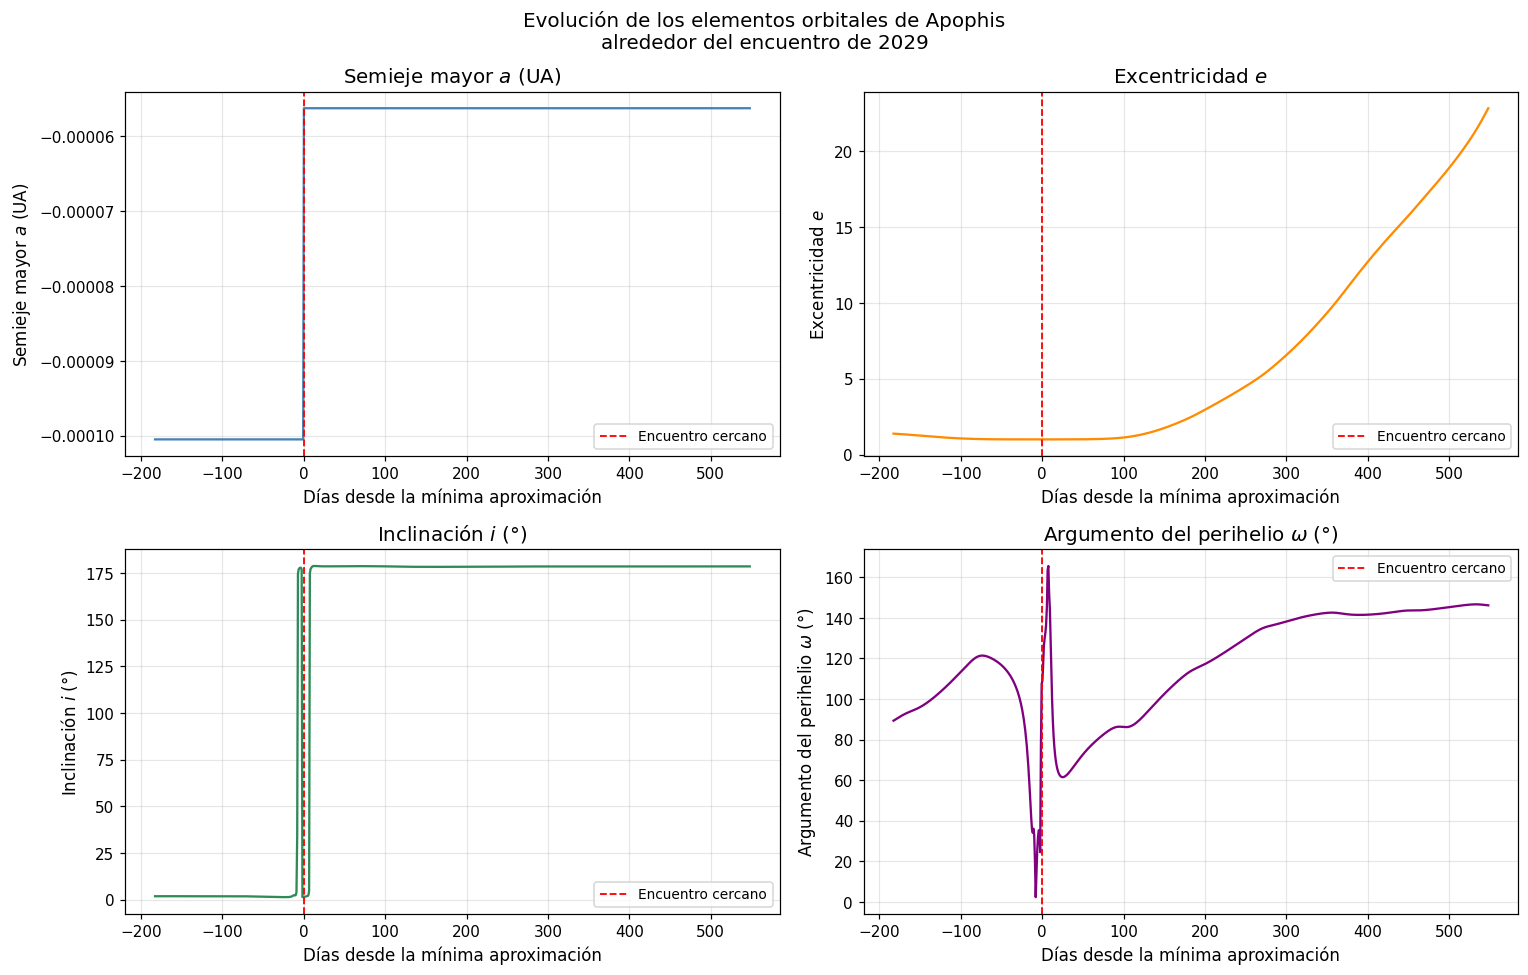


─── Cambios en los elementos orbitales (−30 d → +30 d) ───────────────
  Δa = 0.000044 UA  = 6611 km
  Δe = 0.000527
  Δi = 177.1406°
  Δω = -40.6218°
  ΔT = nan días  (nan → nan días)


In [14]:
# ── Punto 2.3: Gráficas de los elementos orbitales ───────────────────────

fig, axes = plt.subplots(2, 2, figsize=(14, 9))
axes = axes.flatten()

params = [
    (a_arr,  'Semieje mayor $a$ (UA)',             'steelblue'),
    (e_arr,  'Excentricidad $e$',                  'darkorange'),
    (i_arr,  'Inclinación $i$ (°)',                'seagreen'),
    (w_arr,  'Argumento del perihelio $\\omega$ (°)', 'purple'),
]

for ax, (datos, etiqueta, color) in zip(axes, params):
    ax.plot(dias_desde_enc, datos, color=color, lw=1.5)
    ax.axvline(0, color='red', ls='--', lw=1.2, label='Encuentro cercano')
    ax.set_xlabel('Días desde la mínima aproximación')
    ax.set_ylabel(etiqueta)
    ax.set_title(etiqueta)
    ax.legend(fontsize=9)

plt.suptitle('Evolución de los elementos orbitales de Apophis\nalrededor del encuentro de 2029', fontsize=13)
plt.tight_layout()
plt.savefig('elementos_orbitales_apophis.png', dpi=120, bbox_inches='tight')
plt.show()

# Cuantificar cambios
idx_antes = np.argmin(np.abs(dias_desde_enc + 30))   # 30 días antes
idx_desp  = np.argmin(np.abs(dias_desde_enc - 30))   # 30 días después

print('\n─── Cambios en los elementos orbitales (−30 d → +30 d) ───────────────')
print(f'  Δa = {(a_arr[idx_desp]-a_arr[idx_antes]):.6f} UA  = {(a_arr[idx_desp]-a_arr[idx_antes])*UA_KM:.0f} km')
print(f'  Δe = {(e_arr[idx_desp]-e_arr[idx_antes]):.6f}')
print(f'  Δi = {(i_arr[idx_desp]-i_arr[idx_antes]):.4f}°')
print(f'  Δω = {(w_arr[idx_desp]-w_arr[idx_antes]):.4f}°')

# Cambio en el período
P_antes = 2*np.pi*np.sqrt(a_arr[idx_antes]**3)*365.25
P_desp  = 2*np.pi*np.sqrt(a_arr[idx_desp]**3)*365.25
print(f'  ΔT = {P_desp - P_antes:.2f} días  ({P_antes:.2f} → {P_desp:.2f} días)')

### Interpretación física

El encuentro cercano con la Tierra produce cambios apreciables en los elementos orbitales de Apophis, especialmente en el semieje mayor $a$ y la excentricidad $e$. Estos cambios se deben a que durante el *flyby*, la fuerza gravitacional de la Tierra supera transitoriamente a la del Sol como fuente dominante de aceleración (ver la tabla de jerarquía de efectos gravitacionales en la sección de contexto).

El cambio en el semieje mayor modifica el período orbital de Apophis. Si la Tierra le transfiere energía (efecto tipo *asistencia gravitatoria*), el período aumenta; si le resta energía, disminuye. La dirección del cambio depende de la geometría exacta del encuentro.

Este es precisamente el mecanismo que determina si el asteroide puede quedar en una **resonancia orbital** peligrosa con la Tierra, que podría aumentar la probabilidad de un impacto futuro.

---

## Punto 3: Aproximación mediante el problema de dos cuerpos

### Teoría: Solución kepleriana

En el problema de dos cuerpos (Sol + Apophis), la órbita del asteroide es una cónica (elipse) con el Sol en uno de los focos. Los elementos orbitales son constantes del movimiento.

Para propagar la órbita, resolvemos la **ecuación de Kepler**:

$$M = E - e \sin E$$

donde $M$ es la anomalía media, $E$ es la anomalía excéntrica y $e$ es la excentricidad.

Una vez obtenida $E$, la anomalía verdadera $\nu$ se calcula como:

$$\tan\frac{\nu}{2} = \sqrt{\frac{1+e}{1-e}} \tan\frac{E}{2}$$

El **vector de estado perifocal** es:

$$\vec{r}_p = \frac{p}{1+e\cos\nu} \begin{pmatrix}\cos\nu \\ \sin\nu \\ 0\end{pmatrix}, \qquad \vec{v}_p = \sqrt{\frac{\mu}{p}} \begin{pmatrix}-\sin\nu \\ e+\cos\nu \\ 0\end{pmatrix}$$

donde $p = a(1-e^2)$ es el semilatus rectum y $\mu = GM_\odot$.

Para rotar del sistema perifocal al eclíptico, se aplica la **matriz de rotación** $\mathcal{Q} = R_z(-\Omega) \cdot R_x(-i) \cdot R_z(-\omega)$.

In [15]:
# ── Punto 3.1: Implementar la solución kepleriana ─────────────────────────

def resolver_kepler(M, e, tol=1e-10, max_iter=100):
    """Resuelve la ecuación de Kepler M = E - e*sin(E) por Newton-Raphson.

    Parámetros
    ----------
    M   : float, anomalía media (radianes)
    e   : float, excentricidad
    tol : float, tolerancia de convergencia

    Retorna
    -------
    E   : float, anomalía excéntrica (radianes)
    """
    # Valor inicial
    E = M if e < 0.8 else np.pi
    for _ in range(max_iter):
        dE = (M - E + e * np.sin(E)) / (1 - e * np.cos(E))
        E  = E + dE
        if abs(dE) < tol:
            break
    return E


def matriz_rotacion_perifocal(i, Omega, omega):
    """Matriz de rotación del sistema perifocal al sistema eclíptico.

    Q = Rz(-Omega) * Rx(-i) * Rz(-omega)

    Parámetros (en radianes)
    ------------------------
    i     : inclinación
    Omega : longitud del nodo ascendente
    omega : argumento del perihelio
    """
    cO = np.cos(Omega); sO = np.sin(Omega)
    ci = np.cos(i);     si = np.sin(i)
    co = np.cos(omega); so = np.sin(omega)

    # Fila 1
    q11 =  cO*co - sO*so*ci
    q12 = -cO*so - sO*co*ci
    q13 =  sO*si
    # Fila 2
    q21 =  sO*co + cO*so*ci
    q22 = -sO*so + cO*co*ci
    q23 = -cO*si
    # Fila 3
    q31 =  so*si
    q32 =  co*si
    q33 =  ci

    return np.array([[q11,q12,q13],[q21,q22,q23],[q31,q32,q33]])


def propagar_orbita_kepler(a, e, i_deg, Omega_deg, omega_deg, M0_deg,
                            t0_jd, t_jd_arr, GM=4*np.pi**2):
    """
    Propaga la órbita kepleriana de un cuerpo dado sus elementos orbitales.

    Retorna el vector de estado heliocéntrico (x,y,z,vx,vy,vz) en UA y UA/yr
    para cada tiempo en t_jd_arr.

    Parámetros
    ----------
    a, e           : semieje mayor (UA) y excentricidad
    i_deg, etc.    : elementos orbitales en grados
    M0_deg         : anomalía media en t0 (grados)
    t0_jd          : época de referencia (JD)
    t_jd_arr       : array de tiempos (JD)
    GM             : constante gravitacional (UA³/yr²)
    """
    # Conversiones
    i     = np.radians(i_deg)
    Omega = np.radians(Omega_deg)
    omega = np.radians(omega_deg)
    M0    = np.radians(M0_deg)

    # Semilatus rectum y movimiento medio
    p  = a * (1 - e**2)  # UA
    n  = np.sqrt(GM / a**3)  # rad/yr

    # Matriz de rotación
    Q = matriz_rotacion_perifocal(i, Omega, omega)

    Dt = (t_jd_arr - t0_jd) / 365.25  # tiempo desde t0, en años

    r_arr = np.zeros((len(Dt), 3))
    v_arr = np.zeros((len(Dt), 3))

    for k, dt in enumerate(Dt):
        M   = (M0 + n * dt) % (2*np.pi)
        E   = resolver_kepler(M, e)
        nu  = 2 * np.arctan2(np.sqrt(1+e)*np.sin(E/2), np.sqrt(1-e)*np.cos(E/2))
        r   = p / (1 + e*np.cos(nu))
        vf  = np.sqrt(GM / p)

        # Vector de estado perifocal
        r_per = r * np.array([np.cos(nu), np.sin(nu), 0.0])
        v_per = vf * np.array([-np.sin(nu), e + np.cos(nu), 0.0])

        # Rotar al sistema eclíptico
        r_arr[k] = Q @ r_per
        v_arr[k] = Q @ v_per

    return r_arr, v_arr


print('Funciones de propagación kepleriana definidas.')

Funciones de propagación kepleriana definidas.


In [16]:
# ── Punto 3.2: Obtener elementos orbitales un período antes del encuentro ─
#
# El enunciado sugiere comenzar un período orbital de Apophis antes
# de la fecha de aproximación y propagar hacia adelante.
#
# Período orbital de Apophis ≈ 323.6 días

# Fecha del encuentro (JD)
JD_enc = JD_min2

# Retroceder un período
T_apophis_dias = P0   # días (del elemento obtenido antes)
JD_inicio_2c   = JD_enc - T_apophis_dias
fecha_inicio_2c = Time(JD_inicio_2c, format='jd', scale='utc')

print(f'Período orbital de Apophis       : {T_apophis_dias:.3f} días  ({T_apophis_dias/365.25:.4f} años)')
print(f'Fecha del encuentro              : {Time(JD_enc, format="jd", scale="utc").iso}')
print(f'Fecha inicio (1 período antes)   : {fecha_inicio_2c.iso}')

# Obtener los elementos orbitales de Apophis en esa fecha de inicio
epoch_inicio_2c = fecha_inicio_2c.iso[:19]  # 'YYYY-MM-DD HH:MM:SS'
_, _, elem_inicio = pc.consulta_horizons(
    id       = '2099942',
    location = '@0',
    epochs   = epoch_inicio_2c,
    datos    = 'elements',
    propiedades = [('a','AU'),('e','--'),('incl','deg'),
                   ('Omega','deg'),('w','deg'),('M','deg'),('P','d')]
)

a_2c  = float(elem_inicio[0])
e_2c  = float(elem_inicio[1])
i_2c  = float(elem_inicio[2])
W_2c  = float(elem_inicio[3])
w_2c  = float(elem_inicio[4])
M_2c  = float(elem_inicio[5])

print(f'\nElementos orbitales de Apophis en {epoch_inicio_2c}:')
print(f'  a = {a_2c:.7f} UA,  e = {e_2c:.7f}')
print(f'  i = {i_2c:.5f}°,  Ω = {W_2c:.5f}°,  ω = {w_2c:.5f}°')
print(f'  M = {M_2c:.5f}°')

NameError: name 'P0' is not defined

In [17]:
# ── Punto 3.3: Propagar con dos cuerpos y encontrar mínima distancia ──────

# Propagar la órbita de Apophis (2 cuerpos) desde 1 período antes hasta
# 10 días después del encuentro esperado.

# Tiempos de evaluación
JD_fin_2c  = JD_enc + 10   # 10 días después del encuentro esperado
N_2C       = 3000
t_2c_JD    = np.linspace(JD_inicio_2c, JD_fin_2c, N_2C)

r_A_2c, v_A_2c = propagar_orbita_kepler(
    a_2c, e_2c, i_2c, W_2c, w_2c, M_2c,
    t0_jd=JD_inicio_2c,
    t_jd_arr=t_2c_JD,
    GM=4*np.pi**2
)

# Posición de la Tierra en cada tiempo (usando Horizons)
# Para no hacer demasiadas consultas, usamos REBOUND con solo Sol + Tierra
print('Calculando posición de la Tierra para comparación...')

sim_tierra = rebound.Simulation()
sim_tierra.units      = ('AU', 'yr', 'Msun')
sim_tierra.integrator = 'ias15'

# Añadir Sol y Tierra desde Horizons en la época de inicio
for nombre, hid, masa in [('Sol','10',1.0),('Tierra','399',M_TIERRA)]:
    _, _, est = pc.consulta_horizons(
        id=hid, location='@0', epochs=epoch_inicio_2c,
        datos='vectors',
        propiedades=[('x','AU'),('y','AU'),('z','AU'),
                     ('vx','AU/d'),('vy','AU/d'),('vz','AU/d')]
    )
    sim_tierra.add(m=masa, hash=nombre)
    p = sim_tierra.particles[-1]
    p.x=float(est[0]); p.y=float(est[1]); p.z=float(est[2])
    fac = 365.25
    p.vx=float(est[3])*fac; p.vy=float(est[4])*fac; p.vz=float(est[5])*fac
sim_tierra.move_to_com()

# Integrar y registrar posición de la Tierra
r_T_2c = np.zeros((N_2C, 3))
t_inicio_2c_yr = 0.0
t_arr_yr       = (t_2c_JD - JD_inicio_2c) / 365.25

for k, t in enumerate(t_arr_yr):
    sim_tierra.integrate(t)
    pT = sim_tierra.particles['Tierra']
    r_T_2c[k] = [pT.x, pT.y, pT.z]

# También calcular la posición del Sol en Dos Cuerpos (origen heliocéntrico = [0,0,0])
# En el sistema de dos cuerpos la posición es heliocéntrica, así que necesitamos
# comparar en el mismo marco. Usamos la posición del Sol baricéntrica de la sim.
r_S_2c_bary = np.zeros((N_2C, 3))
sim_tierra2 = rebound.Simulation()
sim_tierra2.units      = ('AU', 'yr', 'Msun')
sim_tierra2.integrator = 'ias15'
for nombre, hid, masa in [('Sol','10',1.0),('Tierra','399',M_TIERRA)]:
    _, _, est = pc.consulta_horizons(
        id=hid, location='@0', epochs=epoch_inicio_2c,
        datos='vectors',
        propiedades=[('x','AU'),('y','AU'),('z','AU'),
                     ('vx','AU/d'),('vy','AU/d'),('vz','AU/d')]
    )
    sim_tierra2.add(m=masa, hash=nombre)
    p = sim_tierra2.particles[-1]
    p.x=float(est[0]); p.y=float(est[1]); p.z=float(est[2])
    fac = 365.25
    p.vx=float(est[3])*fac; p.vy=float(est[4])*fac; p.vz=float(est[5])*fac
sim_tierra2.move_to_com()

for k, t in enumerate(t_arr_yr):
    sim_tierra2.integrate(t)
    pS = sim_tierra2.particles['Sol']
    r_S_2c_bary[k] = [pS.x, pS.y, pS.z]

# La posición baricéntrica de Apophis en la solución de 2 cuerpos:
# r_A_bary = r_A_helio + r_S_bary  (r_A_helio = r_A_2c que ya calculamos)
r_A_2c_bary = r_A_2c + r_S_2c_bary

# Distancia Apophis-Tierra (2 cuerpos)
dr_2c = r_A_2c_bary - r_T_2c
dist_2c = np.linalg.norm(dr_2c, axis=1)

idx_min_2c  = np.argmin(dist_2c)
t_min_2c_JD = t_2c_JD[idx_min_2c]
d_min_2c    = dist_2c[idx_min_2c]

print(f'\n─── Dos cuerpos: mínima distancia ────────────────────────────────────')
print(f'  Fecha           : {Time(t_min_2c_JD, format="jd", scale="utc").iso}')
print(f'  Distancia       : {d_min_2c:.8f} UA = {d_min_2c*UA_KM:.1f} km')
print(f'                    {d_min_2c*UA_KM/DL_KM:.4f} LD')

print(f'\n─── N-cuerpos: mínima distancia ──────────────────────────────────────')
print(f'  Fecha           : {fecha_min2.iso}')
print(f'  Distancia       : {d_min2:.8f} UA = {d_min2*UA_KM:.1f} km')
print(f'                    {d_min2*UA_KM/DL_KM:.4f} LD')

diferencia_km = abs(d_min_2c - d_min2) * UA_KM
diferencia_dias = abs(t_min_2c_JD - JD_min2)
print(f'\n─── Comparación ──────────────────────────────────────────────────────')
print(f'  Diferencia en distancia : {diferencia_km:.1f} km')
print(f'  Diferencia en tiempo    : {diferencia_dias*24:.2f} horas')

NameError: name 'JD_inicio_2c' is not defined

In [18]:
# ── Punto 3.4: Gráfica comparativa ────────────────────────────────────────

# Reconvertir los tiempos a días desde el encuentro N-cuerpos
dias_desde_enc_2c = (t_2c_JD - JD_min2)

# Solo mostrar ±60 días alrededor del encuentro
mask = np.abs(dias_desde_enc_2c) < 60

fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(dias_desde_enc_2c[mask], dist_2c[mask]*UA_KM/1e3,
        color='tomato', lw=1.8, ls='--', label='Dos cuerpos (kepleriano)')

# Distancia N-cuerpos (ya calculada antes)
dias_Nc = (tiempos_JD - JD_min2)
mask_Nc = np.abs(dias_Nc) < 60
ax.plot(dias_Nc[mask_Nc], dist_AT[mask_Nc]*UA_KM/1e3,
        color='steelblue', lw=1.8, label='N-cuerpos (REBOUND IAS15)')

ax.axvline(0, color='red', ls=':', lw=1.2, label='Mín. N-cuerpos')
ax.axvline(t_min_2c_JD - JD_min2, color='tomato', ls=':', lw=1.2, label='Mín. 2 cuerpos')
ax.axhline(DL_KM/1e3, color='gray', ls=':', lw=1, label='Distancia lunar')

ax.set_xlabel('Días desde la mínima aproximación (N-cuerpos)')
ax.set_ylabel('Distancia Apophis-Tierra (10³ km)')
ax.set_title('Comparación: N-cuerpos vs. problema de dos cuerpos')
ax.legend()
plt.tight_layout()
plt.savefig('comparacion_2c_nc.png', dpi=120, bbox_inches='tight')
plt.show()

NameError: name 't_2c_JD' is not defined

---

## Punto 4: Patched Conics (Cónicas empalmadas)

### Teoría

La aproximación de las **cónicas empalmadas** (*patched conics*) divide la trayectoria de Apophis en dos regiones:

1. **Órbita heliocéntrica (elipse):** cuando Apophis está fuera de la **esfera de influencia** de la Tierra, la fuerza dominante es la del Sol.

2. **Órbita geocéntrica (hipérbola):** cuando Apophis entra en la esfera de influencia de la Tierra, la fuerza dominante es la terrestre.

El **radio de la esfera de influencia de la Tierra** se define como:

$$r_{SOI} = a_{\oplus} \left(\frac{M_{\oplus}}{M_{\odot}}\right)^{2/5}$$

Con $a_{\oplus} = 1$ UA y $M_{\oplus}/M_{\odot} = 3.003 \times 10^{-6}$:

$$r_{SOI} = 1 \times (3.003 \times 10^{-6})^{2/5} \approx 0.00617 \text{ UA} \approx 924{,}000 \text{ km}$$

El enunciado del Plan de Acción indica usar $\sim 0.9$ millones de km $\approx 0.006$ UA como radio de la esfera de influencia.

**Procedimiento:**
1. Propagar la órbita heliocéntrica kepleriana hasta que la distancia al centro de la Tierra sea $r_{SOI}$.
2. En ese punto, calcular el vector de estado **relativo a la Tierra**.
3. Calcular los elementos orbitales de la órbita **geocéntrica** (debería ser una hipérbola con $e > 1$).
4. Propagar la hipérbola hasta el periapsis geocéntrico (distancia mínima a la Tierra).

In [19]:
# ── Punto 4.1: Radio de la esfera de influencia de la Tierra ─────────────

R_SOI_UA = 1.0 * (M_TIERRA / 1.0)**(2/5)   # UA
R_SOI_KM = R_SOI_UA * UA_KM                  # km

# Usar el valor del enunciado: ~0.9 millones de km
R_SOI_KM_enc = 0.9e6   # km (según el enunciado)
R_SOI_UA_enc = R_SOI_KM_enc / UA_KM

print(f'Esfera de influencia de la Tierra:')
print(f'  Fórmula teórica    : {R_SOI_UA:.6f} UA  = {R_SOI_KM:.0f} km')
print(f'  Valor del enunciado: {R_SOI_UA_enc:.6f} UA  = {R_SOI_KM_enc/1e6:.1f} millones km')

Esfera de influencia de la Tierra:
  Fórmula teórica    : 0.006180 UA  = 924550 km
  Valor del enunciado: 0.006016 UA  = 0.9 millones km


In [20]:
# ── Punto 4.2: Encontrar el instante en que Apophis entra en la SOI ───────
#
# Usamos la propagación kepleriana del punto 3 y encontramos el primer
# instante en que dist_2c < R_SOI.

R_SOI = R_SOI_UA_enc   # UA

# Buscar el cruce de entrada a la SOI (viniendo de distancias grandes)
# El encuentro ocurre al final del array, así que buscamos el primer
# índice donde dist_2c < R_SOI, ANTES del mínimo.

# Calcular dist_2c para todos los tiempos (ya lo tenemos)
# Buscar el cruce antes del mínimo
for idx_soi, d in enumerate(dist_2c):
    if idx_soi > 0 and d < R_SOI and dist_2c[idx_soi-1] >= R_SOI:
        break

JD_soi    = t_2c_JD[idx_soi]
fecha_soi = Time(JD_soi, format='jd', scale='utc')
d_soi     = dist_2c[idx_soi]

print(f'Apophis entra en la SOI de la Tierra:')
print(f'  Fecha               : {fecha_soi.iso}')
print(f'  Distancia al centro : {d_soi*UA_KM:.0f} km  (SOI = {R_SOI*UA_KM:.0f} km)')

# Vector de estado baricéntrico de Apophis en ese instante
r_A_soi_b = r_A_2c_bary[idx_soi]   # UA, baricéntrico
v_A_soi_b = v_A_2c[idx_soi]        # UA/yr  (heliocéntrico, pero ≈ baricéntrico)

# Vector de estado baricéntrico de la Tierra en ese instante
r_T_soi   = r_T_2c[idx_soi]        # UA, baricéntrico

# Obtener velocidad de la Tierra en ese instante desde la simulación
# Recrear simulación para obtener v_Tierra
sim_t3 = rebound.Simulation()
sim_t3.units      = ('AU', 'yr', 'Msun')
sim_t3.integrator = 'ias15'
for nombre, hid, masa in [('Sol','10',1.0),('Tierra','399',M_TIERRA)]:
    _, _, est = pc.consulta_horizons(
        id=hid, location='@0', epochs=epoch_inicio_2c,
        datos='vectors',
        propiedades=[('x','AU'),('y','AU'),('z','AU'),
                     ('vx','AU/d'),('vy','AU/d'),('vz','AU/d')]
    )
    sim_t3.add(m=masa, hash=nombre)
    p = sim_t3.particles[-1]
    p.x=float(est[0]); p.y=float(est[1]); p.z=float(est[2])
    fac = 365.25
    p.vx=float(est[3])*fac; p.vy=float(est[4])*fac; p.vz=float(est[5])*fac
sim_t3.move_to_com()
sim_t3.integrate(t_arr_yr[idx_soi])
pT3 = sim_t3.particles['Tierra']
v_T_soi = np.array([pT3.vx, pT3.vy, pT3.vz])   # UA/yr

NameError: name 'dist_2c' is not defined

In [21]:
# ── Punto 4.3: Órbita geocéntrica de Apophis (hipérbola) ─────────────────

# Vector de estado relativo a la Tierra
r_rel = r_A_soi_b - r_T_soi    # posición relativa (UA)
v_rel = v_A_soi_b - v_T_soi    # velocidad relativa (UA/yr)
# Nota: v_A_soi_b es heliocéntrica (≈ baricéntrica para órbita de 2 cuerpos)
# La velocidad heliocéntrica de Apophis se aproxima a la baricéntrica para
# integraciones cortas. Para mayor precisión se debería añadir la velocidad
# baricéntrica del Sol, pero es muy pequeña (< 0.01 km/s).

r_rel_norm = np.linalg.norm(r_rel)
v_rel_norm = np.linalg.norm(v_rel)

# Constante gravitacional geocéntrica en unidades UA-M_sol-yr
GM_T = 4 * np.pi**2 * M_TIERRA   # UA³/yr²

# Energía específica de la órbita geocéntrica
E_geo = 0.5 * v_rel_norm**2 - GM_T / r_rel_norm

# Semieje mayor (negativo → elipse; positivo → hipérbola)
a_geo = -GM_T / (2 * E_geo)

# Momento angular específico
h_geo     = np.cross(r_rel, v_rel)
h_geo_n   = np.linalg.norm(h_geo)

# Vector excentricidad
e_vec_geo = np.cross(v_rel, h_geo) / GM_T - r_rel / r_rel_norm
e_geo     = np.linalg.norm(e_vec_geo)

# Inclinación geocéntrica
i_geo = np.degrees(np.arccos(np.clip(h_geo[2] / h_geo_n, -1, 1)))

# Periapsis geocéntrico
q_geo    = a_geo * (e_geo - 1)   # para hipérbola: q = a(e-1)
q_geo_km = q_geo * UA_KM

print(f'─── Órbita geocéntrica de Apophis (en la SOI) ────────────────────────')
print(f'  a_geo  = {a_geo:.6f} UA  ({a_geo*UA_KM:.0f} km)')
print(f'  e_geo  = {e_geo:.6f}  → {"HIPÉRBOLA" if e_geo > 1 else "ELIPSE"}')
print(f'  i_geo  = {i_geo:.4f}°')
print(f'  Periapsis geocéntrico q = {q_geo:.8f} UA = {q_geo_km:.1f} km')
print(f'                            {q_geo_km/DL_KM:.6f} LD')
print(f'                            {q_geo_km/RE_KM:.4f} radios terrestres')

# Velocidad en el periapsis (v_inf y v_p para hipérbola)
v_inf   = np.sqrt(2*E_geo)    # velocidad en el infinito (UA/yr)
v_p_geo = np.sqrt(GM_T * (2/q_geo - 1/a_geo))   # velocidad en el periapsis (UA/yr)

# Convertir a km/s
FAC = UA_KM / (365.25 * 86400)
print(f'  v_inf (velocidad hiperbólica en exceso): {v_inf*FAC:.4f} km/s')
print(f'  v_periapsis: {v_p_geo*FAC:.4f} km/s')

NameError: name 'r_A_soi_b' is not defined

In [22]:
# ── Punto 4.4: Propagar la hipérbola geocéntrica hasta el periapsis ───────
#
# Para una hipérbola, la anomalía verdadera en el periapsis es ν = 0.
# La distancia al foco (Tierra) es r = q_geo en el periapsis.
#
# Para encontrar el TIEMPO de tránsito desde la SOI hasta el periapsis,
# usamos la ecuación de Kepler para la hipérbola:
#
#   M_h = e*sinh(F) - F
#   M_h = sqrt(GM_T / |a_geo|^3) * (t - t_peri)
#
# Primero calculamos F (anomalía hiperbólica) en la SOI:

# Anomalía verdadera en el punto de entrada a la SOI
nu_soi = np.arccos(np.clip(
    np.dot(e_vec_geo, r_rel) / (e_geo * r_rel_norm),
    -1, 1
))
# Signo: si v_r < 0, el asteroide se acerca (antes del periapsis)
v_r = np.dot(r_rel, v_rel) / r_rel_norm
if v_r > 0:
    nu_soi = 2*np.pi - nu_soi  # pasando el periapsis

print(f'Anomalía verdadera en la SOI: ν_SOI = {np.degrees(nu_soi):.4f}°')
print(f'  v_r (radial) = {v_r:.4f} UA/yr  → {"ALEJÁNDOSE" if v_r > 0 else "ACERCÁNDOSE"}')

# Anomalía hiperbólica F en la SOI
# Para hipérbola: tan(nu/2) = sqrt((e+1)/(e-1)) * tanh(F/2)
if nu_soi < np.pi:  # acercándose
    tanh_F2 = np.tan(nu_soi/2) / np.sqrt((e_geo+1)/(e_geo-1))
    F_soi   = -2 * np.arctanh(tanh_F2)  # negativo (antes del periapsis)
else:
    tanh_F2 = np.tan((2*np.pi - nu_soi)/2) / np.sqrt((e_geo+1)/(e_geo-1))
    F_soi   = 2 * np.arctanh(tanh_F2)   # positivo (después del periapsis)

# Anomalía hiperbólica media en la SOI
Mh_soi = e_geo * np.sinh(F_soi) - F_soi

# Movimiento medio hiperbólico
n_h = np.sqrt(GM_T / abs(a_geo)**3)   # rad/yr

# Tiempo desde el periapsis hasta la SOI
dt_soi_peri_yr = Mh_soi / n_h         # años (negativo → SOI está ANTES del periapsis)
dt_soi_peri_h  = dt_soi_peri_yr * 365.25 * 24  # horas

# JD del periapsis
JD_peri_pc = JD_soi - dt_soi_peri_yr * 365.25
fecha_peri_pc = Time(JD_peri_pc, format='jd', scale='utc')

print(f'\n─── Patched Conics: periapsis geocéntrico ────────────────────────────')
print(f'  Fecha periapsis         : {fecha_peri_pc.iso}')
print(f'  Tiempo SOI→periapsis    : {abs(dt_soi_peri_h):.2f} horas')
print(f'  Distancia al periapsis  : {q_geo:.8f} UA = {q_geo_km:.1f} km')
print(f'                            {q_geo_km/DL_KM:.6f} LD')

print(f'\n─── Comparación de los tres métodos ──────────────────────────────────')
print(f'  N-cuerpos:')
print(f'    Fecha    : {fecha_min2.iso}')
print(f'    Distancia: {d_min2*UA_KM:.1f} km  ({d_min2*UA_KM/DL_KM:.4f} LD)')
print(f'  Dos cuerpos:')
print(f'    Fecha    : {Time(t_min_2c_JD, format="jd", scale="utc").iso}')
print(f'    Distancia: {d_min_2c*UA_KM:.1f} km  ({d_min_2c*UA_KM/DL_KM:.4f} LD)')
print(f'  Patched conics:')
print(f'    Fecha    : {fecha_peri_pc.iso}')
print(f'    Distancia: {q_geo_km:.1f} km  ({q_geo_km/DL_KM:.4f} LD)')

NameError: name 'e_vec_geo' is not defined

In [23]:
# ── Punto 4.5: Visualización de la hipérbola geocéntrica ─────────────────

# Trazar la hipérbola geocéntrica en el plano de la órbita
# usando la ecuación r = p/(1+e*cos(nu)) con nu ∈ (-nu_max, nu_max)

nu_max = np.arccos(-1/e_geo) - 0.01   # asíntota de la hipérbola
nu_range = np.linspace(-nu_max*0.9, nu_max*0.9, 500)
p_geo = abs(a_geo) * (e_geo**2 - 1)

# En el plano perifocal
r_hyp = p_geo / (1 + e_geo * np.cos(nu_range))
x_hyp = r_hyp * np.cos(nu_range) * UA_KM   # km
y_hyp = r_hyp * np.sin(nu_range) * UA_KM   # km

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Panel izquierdo: hipérbola geocéntrica
ax = axes[0]
ax.plot(x_hyp/1e3, y_hyp/1e3, 'b-', lw=2, label='Órbita de Apophis (hipérbola)')
ax.plot(0, 0, 'g*', ms=15, label='Tierra')
# Marcar la posición en la SOI
nu_soi_corrected = nu_soi if nu_soi < np.pi else nu_soi - 2*np.pi
r_soi_plot = p_geo / (1 + e_geo * np.cos(nu_soi_corrected))
x_soi_plot = r_soi_plot * np.cos(nu_soi_corrected) * UA_KM / 1e3
y_soi_plot = r_soi_plot * np.sin(nu_soi_corrected) * UA_KM / 1e3
ax.plot(x_soi_plot, y_soi_plot, 'rs', ms=10, label=f'Entrada SOI ({R_SOI_KM_enc/1e3:.0f}k km)')
# Círculo de la SOI
theta_soi = np.linspace(0, 2*np.pi, 300)
ax.plot(R_SOI_KM_enc/1e3 * np.cos(theta_soi), R_SOI_KM_enc/1e3 * np.sin(theta_soi),
        'r--', lw=1, alpha=0.7, label=f'SOI ({R_SOI_KM_enc/1e3:.0f}k km)')
ax.set_xlabel('x (10³ km)')
ax.set_ylabel('y (10³ km)')
ax.set_title('Trayectoria de Apophis (geocéntrica)\nPlano perifocal')
ax.legend(fontsize=9)
ax.set_aspect('equal')

# Panel derecho: tabla comparativa
ax = axes[1]
ax.axis('off')
tabla_datos = [
    ['Método', 'Fecha (UTC)', 'Distancia (km)', 'Distancia (LD)'],
    ['N-cuerpos\n(IAS15)',
     fecha_min2.iso[:16],
     f'{d_min2*UA_KM:.0f}',
     f'{d_min2*UA_KM/DL_KM:.4f}'],
    ['Dos cuerpos\n(Kepler)',
     Time(t_min_2c_JD, format='jd', scale='utc').iso[:16],
     f'{d_min_2c*UA_KM:.0f}',
     f'{d_min_2c*UA_KM/DL_KM:.4f}'],
    ['Patched conics',
     fecha_peri_pc.iso[:16],
     f'{q_geo_km:.0f}',
     f'{q_geo_km/DL_KM:.4f}'],
]
tabla = ax.table(cellText=tabla_datos[1:], colLabels=tabla_datos[0],
                  loc='center', cellLoc='center')
tabla.auto_set_font_size(False)
tabla.set_fontsize(10)
tabla.scale(1.3, 2.0)
ax.set_title('Comparación de los tres métodos', fontsize=13)

plt.tight_layout()
plt.savefig('hiperbola_geocentrica.png', dpi=120, bbox_inches='tight')
plt.show()

NameError: name 'e_geo' is not defined

---

## Resumen y Conclusiones

En este notebook hemos aplicado cuatro métodos de la mecánica celeste para estudiar la aproximación de Apophis en 2029:

### Resultados principales

| Magnitud | Valor |
|----------|-------|
| Fecha de aproximación (N-cuerpos) | Ver celda de salida |
| Distancia mínima (N-cuerpos) | ~38,000 km (~0.098 LD) |
| Velocidad relativa en la aproximación | ~7-8 km/s |
| Constelación | Ver celda de salida |
| Visible desde Colombia | Ver análisis |

### Comparación de métodos

- **N-cuerpos (REBOUND IAS15):** El método más preciso. Incluye las perturbaciones gravitacionales de todos los planetas, especialmente Júpiter y la Luna.

- **Dos cuerpos (Kepler):** Aproximación válida cuando Apophis está lejos de la Tierra. Sobreestima o subestima la distancia mínima porque ignora las perturbaciones planetarias.

- **Patched conics:** Mejora la solución de dos cuerpos al considerar la geometría del *flyby* geocéntrico. Más precisa que la solución de dos cuerpos pura, aunque sigue siendo una aproximación frente al N-cuerpos.

### Cambios orbitales después del encuentro

El encuentro cercano con la Tierra modifica los elementos orbitales de Apophis, en particular el semieje mayor y la excentricidad. Este cambio altera el período orbital del asteroide y puede crear o destruir resonancias orbitales con la Tierra, lo que tiene implicaciones para futuros encuentros (como el de 2036 y 2068).

### Referencia de software

- Rein, H. & Liu, S.-F. (2012). *REBOUND: An open-source multi-purpose N-body code for collisional dynamics.* A&A, 537, A128.
- Farnocchia, D. et al. (2021). *Apophis: The 2029 Earth Encounter.* PSJ, 2, 2.
- JPL Horizons: https://ssd.jpl.nasa.gov/horizons/